In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv("heart.csv.xls")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [20]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df["target"].value_counts())

(1025, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
ta

In [21]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 723


In [22]:
df = df.drop_duplicates().reset_index(drop=True)

print(df.shape)

(302, 14)


In [23]:
X = df.drop("target", axis=1)
y = df["target"]

In [24]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

In [25]:
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [28]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [30]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(241, 30)
(61, 30)


In [33]:
model = Sequential([
    
    Dense(
        32,
        activation="relu",
        input_shape=(X_train_processed.shape[1],)
    ),
    
    Dropout(0.2),
    
    Dense(
        16,
        activation="relu"
    ),
    
    Dropout(0.2),
    
    Dense(
        1,
        activation="sigmoid"
    )
])

In [34]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [35]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

In [37]:
history = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5990 - auc: 0.6592 - loss: 0.6722 - precision: 0.6949 - recall: 0.4100 - val_accuracy: 0.5306 - val_auc: 0.6909 - val_loss: 0.6599 - val_precision: 0.7222 - val_recall: 0.4194
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6042 - auc: 0.6577 - loss: 0.6546 - precision: 0.6429 - recall: 0.5400 - val_accuracy: 0.6735 - val_auc: 0.8289 - val_loss: 0.5744 - val_precision: 0.7778 - val_recall: 0.6774
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6771 - auc: 0.7451 - loss: 0.5757 - precision: 0.6863 - recall: 0.7000 - val_accuracy: 0.8367 - val_auc: 0.8978 - val_loss: 0.5157 - val_precision: 0.8485 - val_recall: 0.9032
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7552 - auc: 0.8544 - loss: 0.5056 - precision: 0.7524 - recall: 0.7900 - val_accuracy: 0.8571 - val_auc: 0.9238 - val_loss: 0.4645 - val_precision: 0.8750 - val_recall: 0.9032
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━

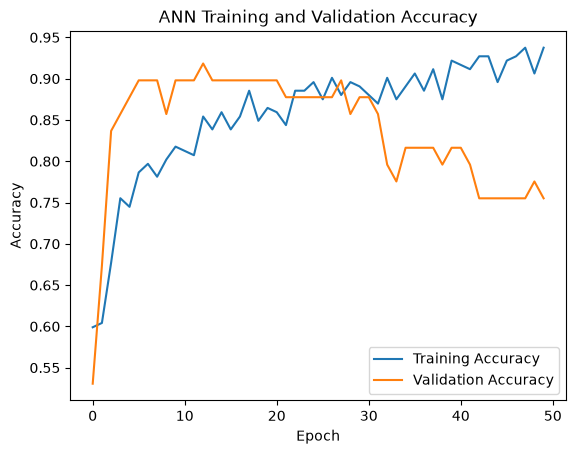

In [38]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Training and Validation Accuracy")
plt.legend()

plt.show()

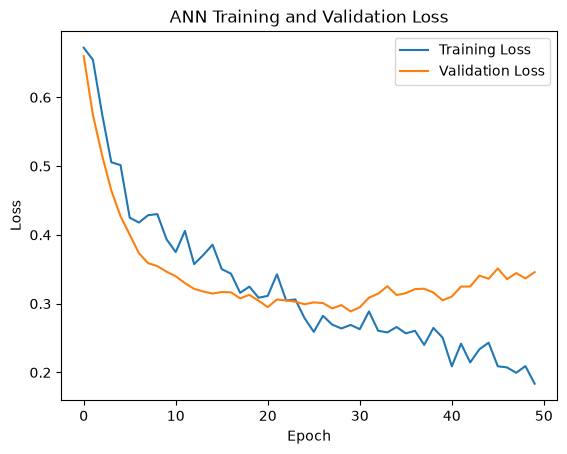

In [39]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training and Validation Loss")
plt.legend()

plt.show()

In [40]:
y_probability = model.predict(X_test_processed).ravel()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [42]:
y_pred = (y_probability >= 0.5).astype(int)

In [43]:
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.8032786885245902


In [44]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.79      0.79      0.79        28
   Heart Disease       0.82      0.82      0.82        33

        accuracy                           0.80        61
       macro avg       0.80      0.80      0.80        61
    weighted avg       0.80      0.80      0.80        61



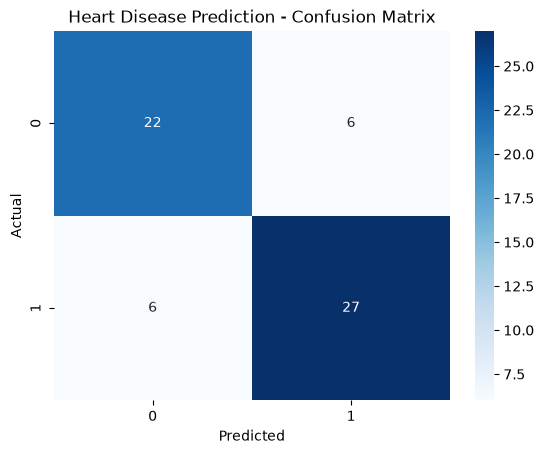

In [45]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Heart Disease Prediction - Confusion Matrix")

plt.show()

In [46]:
auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:", auc)

ROC-AUC: 0.8874458874458875


In [47]:
# New patient information
new_patient = pd.DataFrame([{
    "age": 58,
    "sex": 1,
    "cp": 0,
    "trestbps": 140,
    "chol": 230,
    "fbs": 0,
    "restecg": 1,
    "thalach": 150,
    "exang": 1,
    "oldpeak": 2.0,
    "slope": 1,
    "ca": 1,
    "thal": 2
}])

new_patient

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,58,1,0,140,230,0,1,150,1,2.0,1,1,2


In [48]:

new_patient_processed = preprocessor.transform(new_patient)

# Predict probability
probability = model.predict(new_patient_processed)[0][0]

# Convert probability to class
prediction = 1 if probability >= 0.5 else 0

print(f"Heart Disease Probability: {probability * 100:.2f}%")

if prediction == 1:
    print("Prediction: Heart Disease")
else:
    print("Prediction: No Heart Disease")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Heart Disease Probability: 3.49%
Prediction: No Heart Disease


In [50]:
def predict_heart_disease(
    age,
    sex,
    cp,
    trestbps,
    chol,
    fbs,
    restecg,
    thalach,
    exang,
    oldpeak,
    slope,
    ca,
    thal
):
    
    patient = pd.DataFrame([{
        "age": age,
        "sex": sex,
        "cp": cp,
        "trestbps": trestbps,
        "chol": chol,
        "fbs": fbs,
        "restecg": restecg,
        "thalach": thalach,
        "exang": exang,
        "oldpeak": oldpeak,
        "slope": slope,
        "ca": ca,
        "thal": thal
    }])

    # Preprocess patient
    patient_processed = preprocessor.transform(patient)

    # ANN probability
    probability = model.predict(
        patient_processed,
        verbose=0
    )[0][0]

    # Classification
    prediction = 1 if probability >= 0.5 else 0

    print(f"Heart Disease Probability: {probability * 100:.2f}%")

    if prediction == 1:
        print("Prediction: Heart Disease")
    else:
        print("Prediction: No Heart Disease")

In [54]:
predict_heart_disease(
    age=52,
    sex=1,
    cp=2,
    trestbps=130,
    chol=235,
    fbs=0,
    restecg=1,
    thalach=161,
    exang=0,
    oldpeak=0.2,
    slope=2,
    ca=0,
    thal=2
)

Heart Disease Probability: 96.99%
Prediction: Heart Disease


In [55]:
predict_heart_disease(
    age=67,
    sex=1,
    cp=0,
    trestbps=160,
    chol=286,
    fbs=1,
    restecg=0,
    thalach=108,
    exang=1,
    oldpeak=2.5,
    slope=1,
    ca=2,
    thal=3
)

Heart Disease Probability: 0.04%
Prediction: No Heart Disease


In [56]:
predict_heart_disease(
    age=63,
    sex=1,
    cp=3,
    trestbps=145,
    chol=233,
    fbs=1,
    restecg=0,
    thalach=150,
    exang=0,
    oldpeak=2.3,
    slope=0,
    ca=0,
    thal=1
)

Heart Disease Probability: 71.52%
Prediction: Heart Disease
